# Notebook 12 — Clasificación con KNN y árboles de decisión

En este notebook estudiaremos cómo se adaptan K-Nearest Neighbors y los árboles de decisión a problemas de clasificación.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar qué cambia al pasar de regresión a clasificación;
- ajustar `KNeighborsClassifier`;
- interpretar la votación de vecinos;
- analizar el efecto de \(k\);
- comparar ponderación uniforme y por distancia;
- comprender la importancia del escalamiento en KNN;
- ajustar `DecisionTreeClassifier`;
- interpretar Gini y entropía;
- analizar el efecto de la profundidad y el tamaño de hoja;
- visualizar fronteras de decisión;
- comparar KNN y árboles mediante métricas de clasificación;
- identificar ventajas y limitaciones de cada método.

Usaremos datasets sintéticos bidimensionales para poder visualizar las fronteras aprendidas.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import (
    DecisionTreeClassifier,
    export_text,
    plot_tree,
)

RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format


## 2. Función auxiliar para visualizar fronteras de decisión

In [2]:
def plot_decision_boundary(
    model,
    X,
    y,
    title,
):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500),
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    prediction_grid = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(9, 7))
    plt.contourf(
        xx,
        yy,
        prediction_grid,
        alpha=0.25,
    )

    for class_value in np.unique(y):
        mask = y == class_value
        plt.scatter(
            X[mask, 0],
            X[mask, 1],
            alpha=0.75,
            label=f"Clase {class_value}",
        )

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


## 3. Dataset sintético

Usaremos `make_moons`, que produce una frontera no lineal.

Este dataset permite comparar claramente el comportamiento local de KNN y las particiones rectangulares de los árboles.

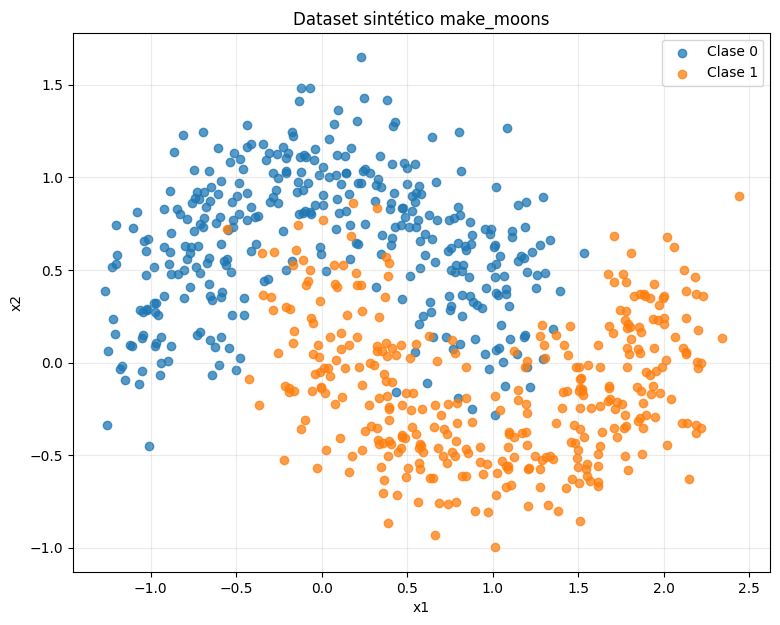

In [3]:
X, y = make_moons(
    n_samples=700,
    noise=0.22,
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(9, 7))

for class_value in np.unique(y):
    mask = y == class_value
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        alpha=0.75,
        label=f"Clase {class_value}",
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset sintético make_moons")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Split estratificado

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")


Train: (525, 2)
Test: (175, 2)


# Parte I. KNN para clasificación

## 5. ¿Qué cambia respecto a regresión?

En KNN para regresión, la predicción es un promedio.

En KNN para clasificación, la predicción se obtiene mediante votación:

\[
\widehat{y}(x^\ast)
=
\operatorname{moda}
\left\{
y_i:
i\in N_k(x^\ast)
\right\}.
\]

También puede estimarse una probabilidad como la proporción de vecinos pertenecientes a cada clase.

## 6. Predicción manual

In [5]:
manual_data = pd.DataFrame({
    "x1": [0.0, 0.5, 1.0, 1.5, 2.0],
    "x2": [0.0, 0.2, 0.1, 1.2, 1.4],
    "clase": [0, 0, 0, 1, 1],
})

query_point = np.array([1.2, 0.8])
k_manual = 3

manual_data["distancia"] = np.sqrt(
    (manual_data["x1"] - query_point[0]) ** 2
    + (manual_data["x2"] - query_point[1]) ** 2
)

nearest_neighbors = manual_data.nsmallest(
    k_manual,
    "distancia",
)

nearest_neighbors


,x1,x2,clase,distancia
3,1.5000,1.2000,1,0.5000
2,1.0000,0.1000,0,0.7280
1,0.5000,0.2000,0,0.9220


In [6]:
manual_prediction = nearest_neighbors["clase"].mode().iloc[0]
manual_probability_class_1 = nearest_neighbors["clase"].mean()

print(f"Clase predicha: {manual_prediction}")
print(
    f"Probabilidad estimada de clase 1: "
    f"{manual_probability_class_1:.3f}"
)


Clase predicha: 0
Probabilidad estimada de clase 1: 0.333


## 7. Primer clasificador KNN

In [7]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=9,
            weights="uniform",
        ),
    ),
])

knn_model.fit(
    X_train,
    y_train,
)

knn_predictions = knn_model.predict(
    X_test
)

knn_probabilities = knn_model.predict_proba(
    X_test
)[:, 1]

pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
    ],
    "Valor": [
        accuracy_score(
            y_test,
            knn_predictions,
        ),
        precision_score(
            y_test,
            knn_predictions,
        ),
        recall_score(
            y_test,
            knn_predictions,
        ),
        f1_score(
            y_test,
            knn_predictions,
        ),
        roc_auc_score(
            y_test,
            knn_probabilities,
        ),
    ],
})


,Métrica,Valor
0,Accuracy,0.9657
1,Precision,0.9551
2,Recall,0.9770
3,F1,0.9659
4,ROC-AUC,0.9950


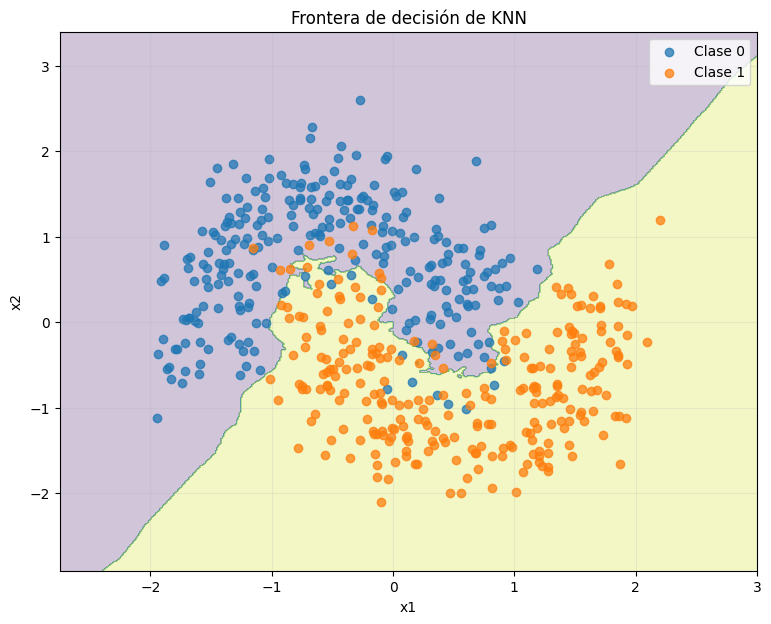

In [8]:
X_train_scaled = knn_model.named_steps["scaler"].transform(
    X_train
)

plot_decision_boundary(
    knn_model.named_steps["knn"],
    X_train_scaled,
    y_train,
    title="Frontera de decisión de KNN",
)


## 8. Efecto de \(k\)

- \(k\) pequeño: frontera irregular y alta varianza;
- \(k\) grande: frontera suave y mayor sesgo.

In [9]:
k_values = [1, 3, 5, 9, 15, 30, 60]
k_results = []

for k_value in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=k_value,
            ),
        ),
    ])

    model.fit(
        X_train,
        y_train,
    )

    train_pred = model.predict(
        X_train
    )
    test_pred = model.predict(
        X_test
    )

    k_results.append({
        "k": k_value,
        "Accuracy train": accuracy_score(
            y_train,
            train_pred,
        ),
        "Accuracy test": accuracy_score(
            y_test,
            test_pred,
        ),
        "F1 test": f1_score(
            y_test,
            test_pred,
        ),
    })

k_results_df = pd.DataFrame(
    k_results
)

k_results_df


,k,Accuracy train,Accuracy test,F1 test
0,1,1.0000,0.9029,0.9017
1,3,0.9467,0.9486,0.9492
2,5,0.9524,0.9600,0.9595
3,9,0.9429,0.9657,0.9659
4,15,0.9410,0.9714,0.9714
5,30,0.9371,0.9714,0.9718
6,60,0.9410,0.9429,0.9425


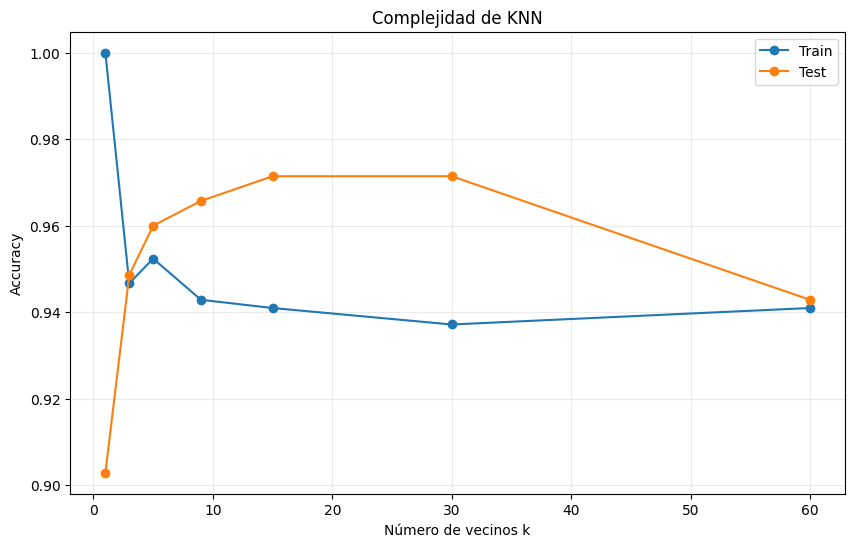

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_results_df["k"],
    k_results_df["Accuracy train"],
    marker="o",
    label="Train",
)

plt.plot(
    k_results_df["k"],
    k_results_df["Accuracy test"],
    marker="o",
    label="Test",
)

plt.xlabel("Número de vecinos k")
plt.ylabel("Accuracy")
plt.title("Complejidad de KNN")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


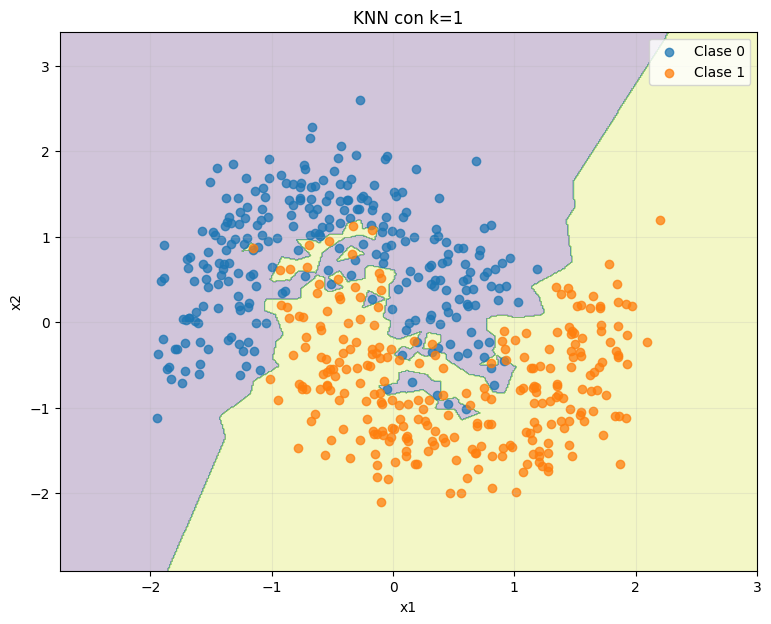

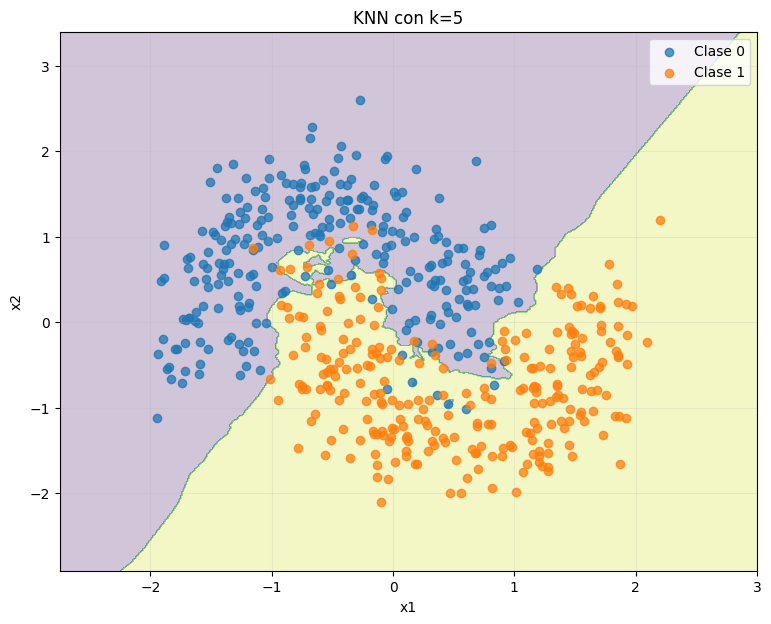

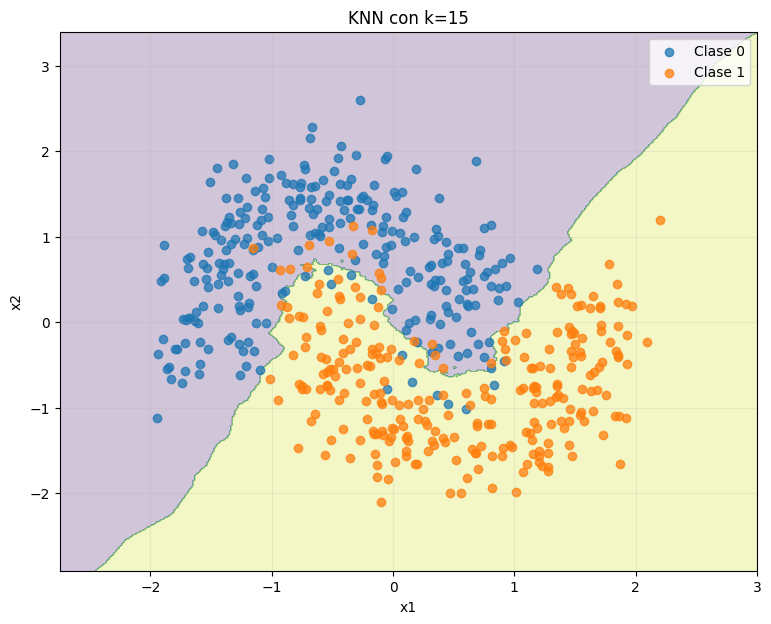

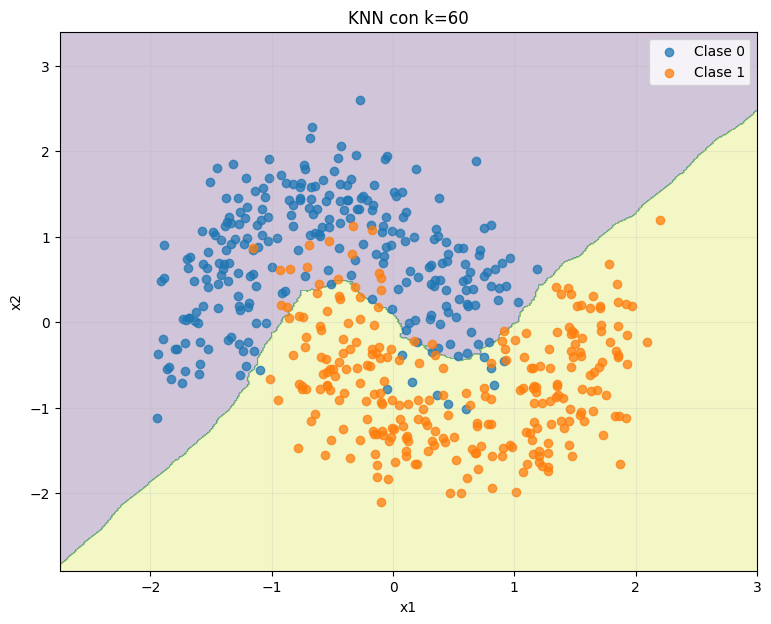

In [11]:
for k_value in [1, 5, 15, 60]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=k_value,
            ),
        ),
    ])

    model.fit(
        X_train,
        y_train,
    )

    X_scaled = model.named_steps["scaler"].transform(
        X_train
    )

    plot_decision_boundary(
        model.named_steps["knn"],
        X_scaled,
        y_train,
        title=f"KNN con k={k_value}",
    )


## 9. Ponderación uniforme y por distancia

Con `weights="distance"` los vecinos más cercanos tienen mayor influencia.

In [12]:
weight_results = []

for weight_type in ["uniform", "distance"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsClassifier(
                n_neighbors=15,
                weights=weight_type,
            ),
        ),
    ])

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:, 1]

    weight_results.append({
        "Ponderación": weight_type,
        "Accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "F1": f1_score(
            y_test,
            predictions,
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities,
        ),
    })

pd.DataFrame(weight_results)


,Ponderación,Accuracy,F1,ROC-AUC
0,uniform,0.9714,0.9714,0.9977
1,distance,0.9657,0.9655,0.9946


## 10. Importancia del escalamiento

Como KNN utiliza distancias, una variable en una escala mayor puede dominar por completo la búsqueda de vecinos.

In [13]:
X_scale = X.copy()
X_scale[:, 1] = X_scale[:, 1] * 10_000

X_train_scale, X_test_scale, y_train_scale, y_test_scale = (
    train_test_split(
        X_scale,
        y,
        test_size=0.25,
        stratify=y,
        random_state=RANDOM_STATE,
    )
)

knn_without_scaling = KNeighborsClassifier(
    n_neighbors=9,
)

knn_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    (
        "knn",
        KNeighborsClassifier(
            n_neighbors=9,
        ),
    ),
])

knn_without_scaling.fit(
    X_train_scale,
    y_train_scale,
)

knn_with_scaling.fit(
    X_train_scale,
    y_train_scale,
)

pd.DataFrame({
    "Modelo": [
        "KNN sin escalamiento",
        "KNN con escalamiento",
    ],
    "Accuracy test": [
        accuracy_score(
            y_test_scale,
            knn_without_scaling.predict(
                X_test_scale
            ),
        ),
        accuracy_score(
            y_test_scale,
            knn_with_scaling.predict(
                X_test_scale
            ),
        ),
    ],
})


,Modelo,Accuracy test
0,KNN sin escalamiento,0.8400
1,KNN con escalamiento,0.9657


# Parte II. Árboles de decisión para clasificación

## 11. ¿Qué cambia respecto a regresión?

En regresión, cada hoja predice un promedio.

En clasificación, cada hoja predice:

- la clase mayoritaria;
- probabilidades basadas en la proporción de clases dentro de la hoja.

Las divisiones buscan reducir impureza.

## 12. Gini y entropía

### Gini

\[
G=1-\sum_{k=1}^{K}p_k^2.
\]

### Entropía

\[
H=-\sum_{k=1}^{K}p_k\log(p_k).
\]

Ambas son bajas cuando un nodo contiene principalmente una sola clase.

## 13. Primer árbol de clasificación

In [14]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=8,
    criterion="gini",
    random_state=RANDOM_STATE,
)

tree_model.fit(
    X_train,
    y_train,
)

tree_predictions = tree_model.predict(
    X_test
)

tree_probabilities = tree_model.predict_proba(
    X_test
)[:, 1]

pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
    ],
    "Valor": [
        accuracy_score(
            y_test,
            tree_predictions,
        ),
        precision_score(
            y_test,
            tree_predictions,
        ),
        recall_score(
            y_test,
            tree_predictions,
        ),
        f1_score(
            y_test,
            tree_predictions,
        ),
        roc_auc_score(
            y_test,
            tree_probabilities,
        ),
    ],
})


,Métrica,Valor
0,Accuracy,0.9314
1,Precision,0.9213
2,Recall,0.9425
3,F1,0.9318
4,ROC-AUC,0.9777


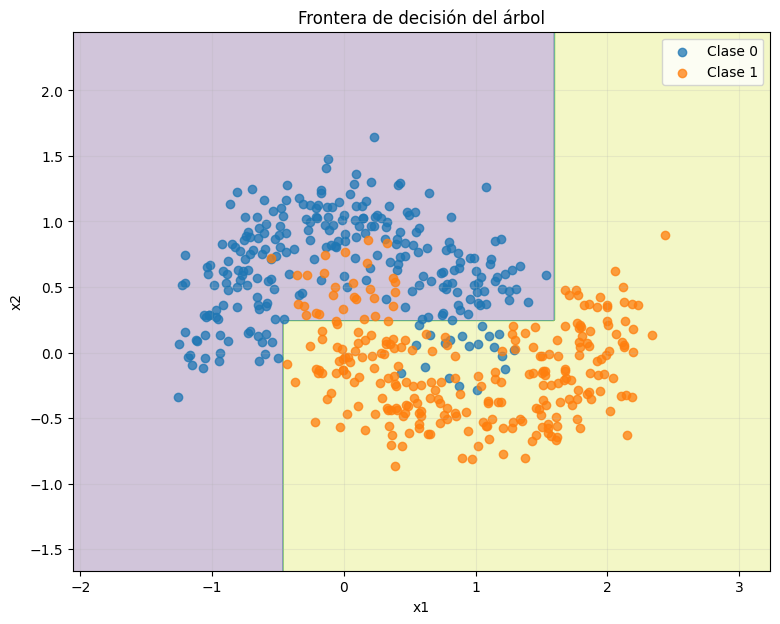

In [15]:
plot_decision_boundary(
    tree_model,
    X_train,
    y_train,
    title="Frontera de decisión del árbol",
)


## 14. Visualización del árbol

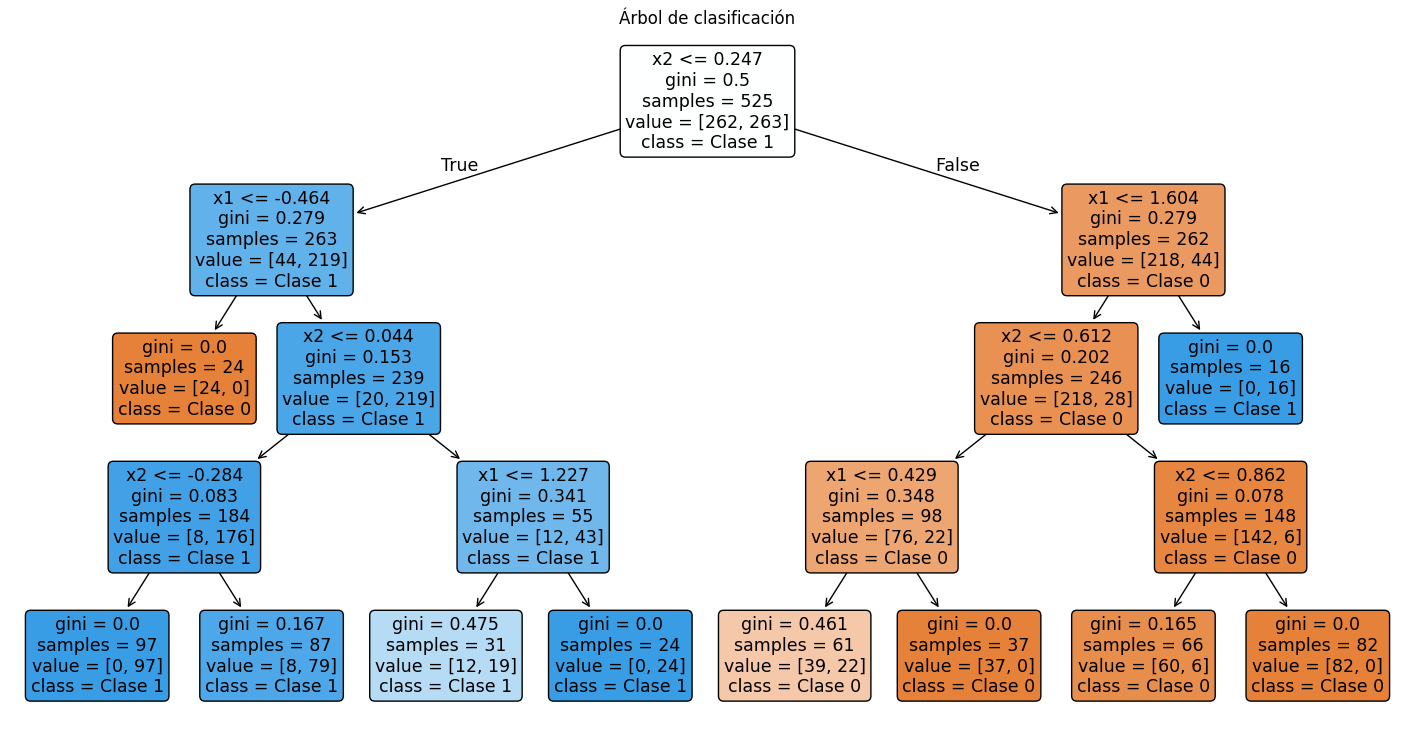

In [16]:
plt.figure(figsize=(18, 9))

plot_tree(
    tree_model,
    feature_names=["x1", "x2"],
    class_names=["Clase 0", "Clase 1"],
    filled=True,
    rounded=True,
    proportion=False,
    precision=3,
)

plt.title("Árbol de clasificación")
plt.show()


In [17]:
print(
    export_text(
        tree_model,
        feature_names=["x1", "x2"],
    )
)


|--- x2 <= 0.25
|   |--- x1 <= -0.46
|   |   |--- class: 0
|   |--- x1 >  -0.46
|   |   |--- x2 <= 0.04
|   |   |   |--- x2 <= -0.28
|   |   |   |   |--- class: 1
|   |   |   |--- x2 >  -0.28
|   |   |   |   |--- class: 1
|   |   |--- x2 >  0.04
|   |   |   |--- x1 <= 1.23
|   |   |   |   |--- class: 1
|   |   |   |--- x1 >  1.23
|   |   |   |   |--- class: 1
|--- x2 >  0.25
|   |--- x1 <= 1.60
|   |   |--- x2 <= 0.61
|   |   |   |--- x1 <= 0.43
|   |   |   |   |--- class: 0
|   |   |   |--- x1 >  0.43
|   |   |   |   |--- class: 0
|   |   |--- x2 >  0.61
|   |   |   |--- x2 <= 0.86
|   |   |   |   |--- class: 0
|   |   |   |--- x2 >  0.86
|   |   |   |   |--- class: 0
|   |--- x1 >  1.60
|   |   |--- class: 1



Cada hoja contiene:

- número de observaciones;
- distribución de clases;
- clase predicha;
- nivel de impureza.

## 15. Efecto de la profundidad

In [18]:
depth_values = [1, 2, 3, 4, 6, 10, None]
depth_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    train_pred = model.predict(
        X_train
    )
    test_pred = model.predict(
        X_test
    )

    depth_results.append({
        "max_depth": str(depth),
        "Profundidad real": model.get_depth(),
        "Hojas": model.get_n_leaves(),
        "Accuracy train": accuracy_score(
            y_train,
            train_pred,
        ),
        "Accuracy test": accuracy_score(
            y_test,
            test_pred,
        ),
    })

depth_results_df = pd.DataFrame(
    depth_results
)

depth_results_df


,max_depth,Profundidad real,Hojas,Accuracy train,Accuracy test
0,1,1,2,0.8324,0.8400
1,2,2,4,0.9086,0.9314
2,3,3,6,0.9086,0.9314
3,4,4,10,0.9086,0.9314
4,6,6,18,0.9581,0.9429
5,10,10,36,0.9867,0.9314
6,None,13,45,1.0000,0.9257


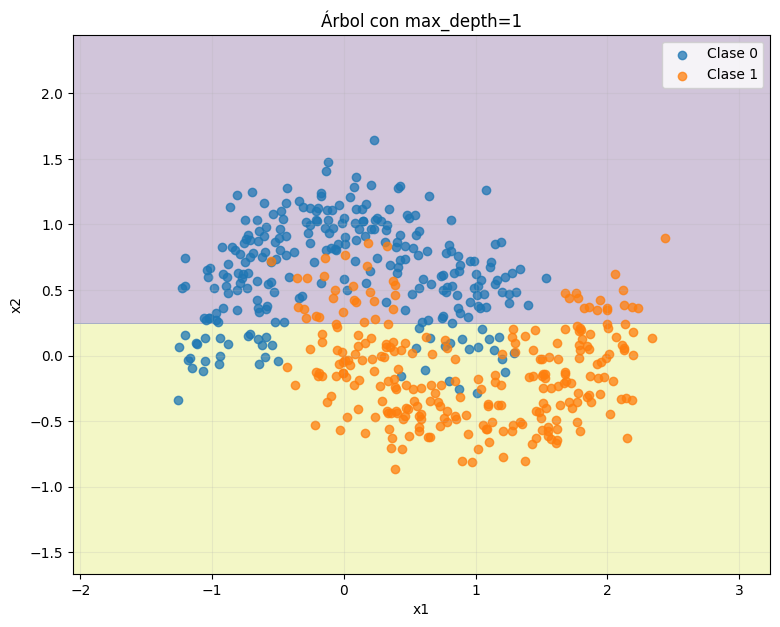

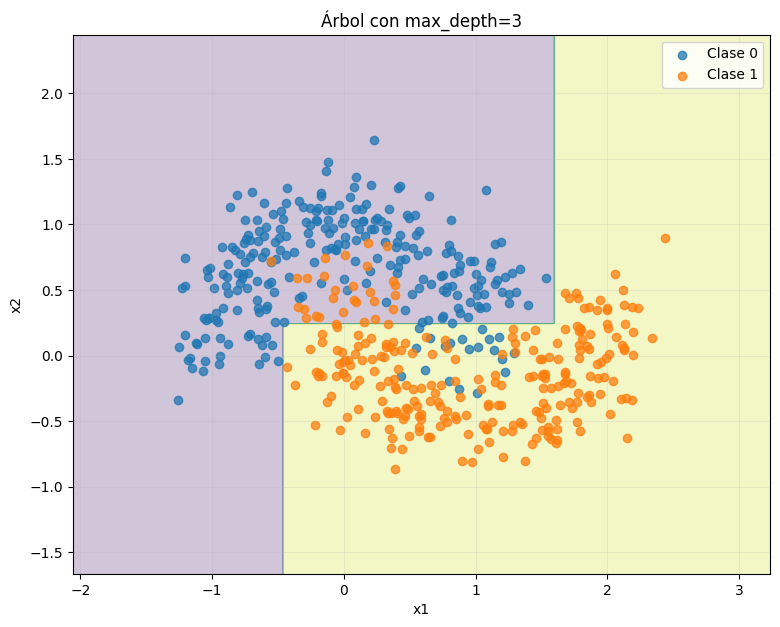

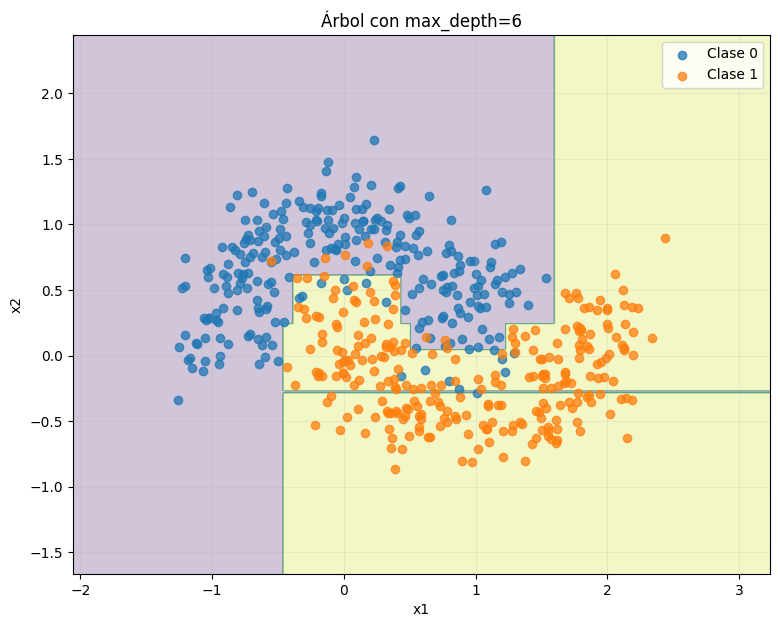

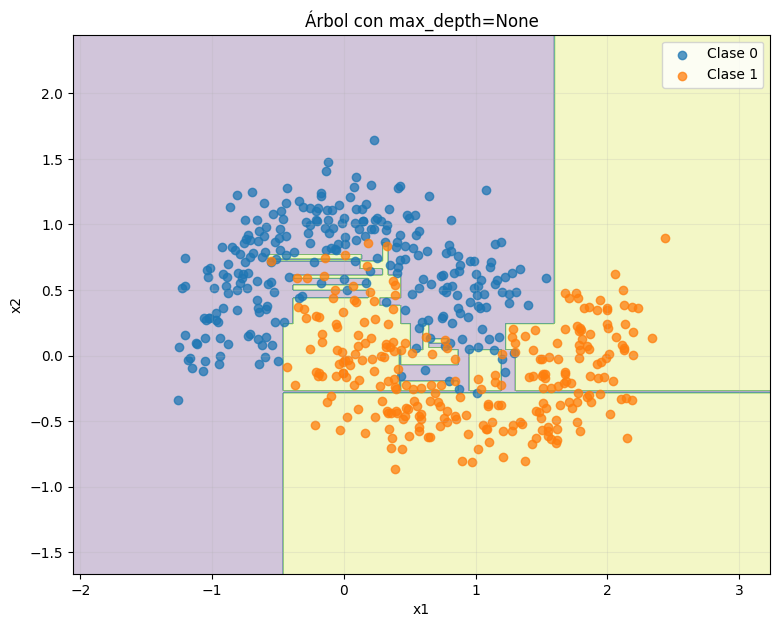

In [19]:
for depth in [1, 3, 6, None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    plot_decision_boundary(
        model,
        X_train,
        y_train,
        title=f"Árbol con max_depth={depth}",
    )


Un árbol sin restricciones puede crear regiones muy pequeñas alrededor de observaciones individuales.

## 16. Gini vs. entropía

In [20]:
criterion_results = []

for criterion_value in ["gini", "entropy"]:
    model = DecisionTreeClassifier(
        criterion=criterion_value,
        max_depth=4,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    predictions = model.predict(
        X_test
    )

    criterion_results.append({
        "Criterio": criterion_value,
        "Accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "F1": f1_score(
            y_test,
            predictions,
        ),
        "Profundidad": model.get_depth(),
        "Hojas": model.get_n_leaves(),
    })

pd.DataFrame(criterion_results)


,Criterio,Accuracy,F1,Profundidad,Hojas
0,gini,0.9314,0.9318,4,10
1,entropy,0.9314,0.9318,4,8


En muchos problemas ambos criterios producen resultados similares. La diferencia suele ser menor que la causada por la profundidad o el tamaño de hoja.

## 17. Probabilidades en árboles

In [21]:
probability_example = tree_model.predict_proba(
    X_test[:10]
)

pd.DataFrame({
    "P(clase 0)": probability_example[:, 0],
    "P(clase 1)": probability_example[:, 1],
    "Clase predicha": tree_model.predict(
        X_test[:10]
    ),
    "Clase real": y_test[:10],
})


,P(clase 0),P(clase 1),Clase predicha,Clase real
0,1.0000,0.0000,0,0
1,0.6393,0.3607,0,0
2,0.6393,0.3607,0,0
3,0.0920,0.9080,1,1
4,0.9091,0.0909,0,0
5,0.0000,1.0000,1,1
6,0.0000,1.0000,1,1
7,0.0000,1.0000,1,1
8,0.9091,0.0909,0,0
9,0.0000,1.0000,1,1


Las probabilidades se calculan a partir de las proporciones observadas en la hoja. En hojas pequeñas pueden ser extremas e inestables.

# Parte III. Comparación entre KNN y árboles

## 18. Evaluación conjunta

In [22]:
comparison_models = {
    "KNN": knn_model,
    "Árbol": tree_model,
}

comparison_rows = []

for model_name, model in comparison_models.items():
    train_pred = model.predict(
        X_train
    )
    test_pred = model.predict(
        X_test
    )
    test_prob = model.predict_proba(
        X_test
    )[:, 1]

    comparison_rows.append({
        "Modelo": model_name,
        "Accuracy train": accuracy_score(
            y_train,
            train_pred,
        ),
        "Accuracy test": accuracy_score(
            y_test,
            test_pred,
        ),
        "Precision test": precision_score(
            y_test,
            test_pred,
        ),
        "Recall test": recall_score(
            y_test,
            test_pred,
        ),
        "F1 test": f1_score(
            y_test,
            test_pred,
        ),
        "ROC-AUC test": roc_auc_score(
            y_test,
            test_prob,
        ),
    })

comparison_table = pd.DataFrame(
    comparison_rows
)

comparison_table


,Modelo,Accuracy train,Accuracy test,Precision test,Recall test,F1 test,ROC-AUC test
0,KNN,0.9429,0.9657,0.9551,0.9770,0.9659,0.9950
1,Árbol,0.9086,0.9314,0.9213,0.9425,0.9318,0.9777


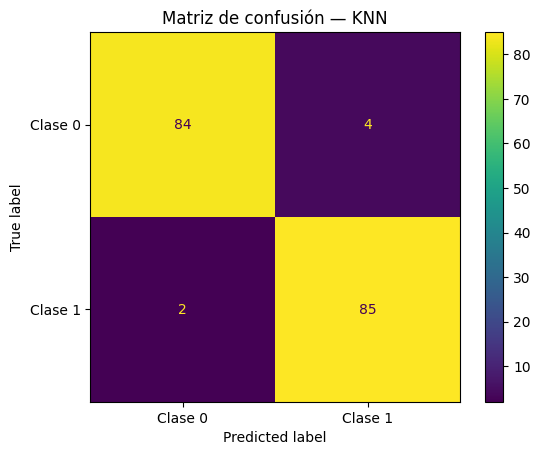

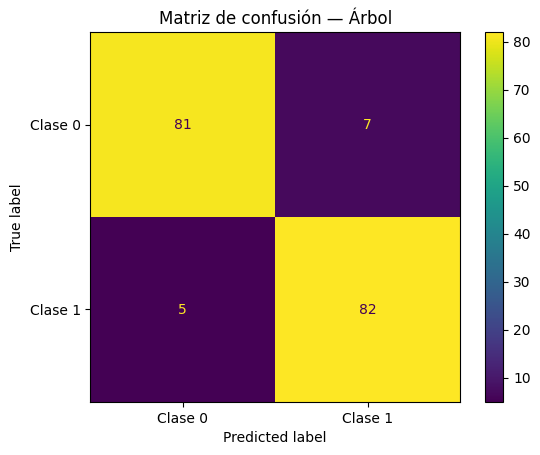

In [23]:
for model_name, model in comparison_models.items():
    predictions = model.predict(
        X_test
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(
            y_test,
            predictions,
        ),
        display_labels=["Clase 0", "Clase 1"],
    ).plot()

    plt.title(
        f"Matriz de confusión — {model_name}"
    )
    plt.show()


## 19. Diferencias prácticas

### KNN

- requiere escalamiento;
- entrenamiento muy rápido;
- predicción potencialmente costosa;
- sensible a variables irrelevantes;
- frontera local y suave según \(k\);
- poca capacidad de extrapolación.

### Árboles

- no requieren escalamiento;
- producen reglas explícitas;
- modelan interacciones automáticamente;
- predicción rápida;
- pueden sobreajustar;
- pequeñas variaciones de datos pueden cambiar la estructura.

## 20. Errores frecuentes

1. Usar KNN sin escalar.
2. Elegir \(k\) con test.
3. Usar \(k=1\) porque ajusta perfectamente.
4. Entrenar árboles sin restricciones.
5. Interpretar Gini como una métrica de desempeño.
6. Pensar que entropía siempre supera a Gini.
7. Interpretar probabilidades de hojas pequeñas como muy confiables.
8. Comparar modelos con splits distintos.
9. Ignorar el costo de predicción de KNN.
10. Interpretar importancia o reglas como causalidad.

## 21. Experimentos sugeridos

### Experimento 1

Compara \(k\) entre 1 y 100.

### Experimento 2

Cambia la métrica de distancia de KNN con `p=1` y `p=2`.

### Experimento 3

Agrega variables irrelevantes.

### Experimento 4

Aumenta el ruido de `make_moons`.

### Experimento 5

Varía `min_samples_leaf` en el árbol.

### Experimento 6

Compara Gini y entropía en varias semillas.

### Experimento 7

Usa un dataset linealmente separable.

### Experimento 8

Usa un dataset con desbalance de clases.

### Experimento 9

Selecciona hiperparámetros mediante validación cruzada.

### Experimento 10

Compara tiempos de entrenamiento y predicción.

## 22. Resumen

En este notebook:

- adaptamos KNN de regresión a clasificación;
- calculamos una votación manual;
- analizamos el efecto de \(k\);
- comparamos ponderación uniforme y por distancia;
- mostramos la necesidad de escalamiento;
- adaptamos árboles de regresión a clasificación;
- estudiamos Gini y entropía;
- visualizamos reglas y fronteras;
- analizamos profundidad y overfitting;
- comparamos KNN y árboles con métricas comunes.

Ambos algoritmos son no paramétricos y flexibles, pero construyen sus predicciones de maneras muy distintas: KNN utiliza proximidad local y los árboles utilizan reglas sucesivas de partición.